Yes. We should do **Option B as a completely standalone fresh experiment**.

This notebook needs **no `variance_curves.csv`, no previous CSV, no old notebook, and no previous fitted parameters**. It independently implements the experiment, generates fresh random initializations, computes the pooled gradient variance, extracts \(\tau_{BP}\), and saves the fresh raw curves.

I recommend using the **same core methodology as the historical baseline**—Brick-Wall HEA, \(RY\) rotations, alternating CNOTs, \(Z_0\otimes\cdots\otimes Z_{k-1}\), uniform \([0,2\pi]\) initialization, 50 parameter sets, pooled gradient variance, and first crossing below \(10^{-2}\). That is necessary for a meaningful validation of the old dataset. The methodology notes explicitly define that pooled estimator. 

# Standalone Fresh Spot Reproduction

### Cell 1 — Setup


In [8]:
# ============================================================
# FRESH INDEPENDENT SPOT REPRODUCTION
# ============================================================
#
# IMPORTANT:
# This notebook intentionally does NOT load:
#   - variance_curves.csv
#   - previous tau data
#   - previous fitted A/c values
#   - previous result files
#
# It performs a fresh independent experiment from the
# methodological specification only.
#
# ============================================================

# Keep numpy<2 pinned for pandas & scipy C-extension compatibility
%pip install -q pennylane "numpy<2"

import os
import time
import json
import pickle
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

print("=" * 80)
print("FRESH INDEPENDENT SPOT REPRODUCTION")
print("=" * 80)

# ------------------------------------------------------------
# Experimental protocol
# ------------------------------------------------------------

THRESHOLD = 1e-2

N_SAMPLES = 50

MAX_DEPTH = 30

# Deliberately chosen before seeing fresh results.
# These span different system sizes and observable supports.
SPOT_CONFIGS = [
    (8, 2),
    (8, 6),
    (10, 4),
    (12, 4),
    (14, 2),
]

# Independent master seed.
# This is a fresh experiment seed and is NOT taken from the
# historical dataset.
MASTER_SEED = 20260901

# ------------------------------------------------------------
# Checkpointing
# ------------------------------------------------------------

OUTPUT_DIR = "fresh_spot_reproduction"
CHECKPOINT_DIR = os.path.join(
    OUTPUT_DIR,
    "checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

CHECKPOINT_FILE = os.path.join(
    CHECKPOINT_DIR,
    "fresh_spot_checkpoint.pkl"
)

RAW_OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "fresh_variance_curves.csv"
)

TAU_OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "fresh_tau_results.csv"
)

print(f"Threshold:             {THRESHOLD}")
print(f"Samples/config/depth:  {N_SAMPLES}")
print(f"Maximum depth:         {MAX_DEPTH}")
print(f"Configurations:        {SPOT_CONFIGS}")
print(f"Master random seed:    {MASTER_SEED}")
print()
print("No previous data are required.")


Note: you may need to restart the kernel to use updated packages.
FRESH INDEPENDENT SPOT REPRODUCTION
Threshold:             0.01
Samples/config/depth:  50
Maximum depth:         30
Configurations:        [(8, 2), (8, 6), (10, 4), (12, 4), (14, 2)]
Master random seed:    20260901

No previous data are required.


### Cell 2 — Verify simulator


In [9]:
# ============================================================
# CELL 2 — SIMULATOR CHECK
# ============================================================

print("=" * 80)
print("PENNYLANE / SIMULATOR CHECK")
print("=" * 80)

print("PennyLane version:", qml.__version__)

try:
    dev = qml.device(
        "lightning.qubit",
        wires=2
    )

    SIMULATOR = "lightning.qubit"

except Exception:

    print(
        "lightning.qubit unavailable; using default.qubit."
    )

    dev = qml.device(
        "default.qubit",
        wires=2
    )

    SIMULATOR = "default.qubit"

print("Simulator:", SIMULATOR)


PENNYLANE / SIMULATOR CHECK
PennyLane version: 0.44.1
Simulator: lightning.qubit


### Cell 3 — Independent Brick-Wall ansatz


In [10]:
# ============================================================
# CELL 3 — BRICK-WALL HEA
# ============================================================
#
# For every layer:
#   1. RY on every qubit
#   2. alternating CNOT layer
#
# Even:
#   (0,1), (2,3), ...
#
# Odd:
#   (1,2), (3,4), ...
# ============================================================

def brickwall_ansatz(
    n_qubits,
    params,
    depth
):

    expected = n_qubits * depth

    if len(params) != expected:
        raise ValueError(
            f"Expected {expected} parameters, "
            f"received {len(params)}."
        )

    idx = 0

    for layer in range(depth):

        # One independent RY per qubit
        for q in range(n_qubits):

            qml.RY(
                params[idx],
                wires=q
            )

            idx += 1

        # Alternating Brick-Wall connectivity
        if layer % 2 == 0:

            for q in range(
                0,
                n_qubits - 1,
                2
            ):

                qml.CNOT(
                    wires=[q, q + 1]
                )

        else:

            for q in range(
                1,
                n_qubits - 1,
                2
            ):

                qml.CNOT(
                    wires=[q, q + 1]
                )


### Cell 4 — Independent observable


In [11]:
# ============================================================
# CELL 4 — k-LOCAL PAULI-Z OBSERVABLE
# ============================================================

def make_observable(k):

    if k < 1:
        raise ValueError(
            "k must be >= 1."
        )

    observable = qml.PauliZ(0)

    for q in range(
        1,
        k
    ):

        observable = (
            observable
            @ qml.PauliZ(q)
        )

    return observable


### Cell 5 — Build one circuit/QNode


In [12]:
# ============================================================
# CELL 5 — QNODE FACTORY
# ============================================================

def make_qnode(
    n_qubits,
    k,
    depth
):

    device = qml.device(
        SIMULATOR,
        wires=n_qubits
    )

    observable = make_observable(k)

    diff_method = "adjoint" if "lightning" in SIMULATOR else "backprop"

    @qml.qnode(
        device,
        diff_method=diff_method
    )
    def cost_fn(params):

        brickwall_ansatz(
            n_qubits,
            params,
            depth
        )

        return qml.expval(
            observable
        )

    return cost_fn


### Cell 6 — One-depth pooled variance


In [13]:
# ============================================================
# CELL 6 — POOLED GRADIENT VARIANCE
# ============================================================
#
# CRITICAL METHODOLOGY:
#
# For each depth:
#
#   seed/sample 1 -> COMPLETE gradient vector
#   seed/sample 2 -> COMPLETE gradient vector
#   ...
#
# Then:
#
#   concatenate ALL gradient components from ALL samples
#   compute ONE variance across the pooled array.
#
# We do NOT:
#   - calculate variance per sample and average
#   - average gradients
#   - use gradient norms
#
# ============================================================

def pooled_gradient_variance(
    n_qubits,
    k,
    depth,
    rng
):

    qnode = make_qnode(
        n_qubits,
        k,
        depth
    )

    all_gradients = []

    for sample in range(
        N_SAMPLES
    ):

        parameter_values = rng.uniform(
            0.0,
            2.0 * np.pi,
            size=n_qubits * depth
        )

        params = qml.numpy.array(
            parameter_values,
            requires_grad=True
        )

        gradient = qml.grad(
            qnode
        )(params)

        gradient = np.asarray(
            gradient,
            dtype=float
        ).reshape(-1)

        if len(gradient) != n_qubits * depth:

            raise RuntimeError(
                "CRITICAL: Gradient vector length does not "
                "equal number of circuit parameters."
            )

        all_gradients.extend(
            gradient.tolist()
        )

    all_gradients = np.asarray(
        all_gradients,
        dtype=float
    )

    expected_components = (
        N_SAMPLES
        * n_qubits
        * depth
    )

    if len(all_gradients) != expected_components:

        raise RuntimeError(
            "CRITICAL: Pooled gradient component count "
            "does not match expected value."
        )

    variance = np.var(
        all_gradients
    )

    return (
        float(variance),
        int(len(all_gradients))
    )


### Cell 7 — Fresh experiment execution


In [14]:
# ============================================================
# CELL 7 — RUN FRESH EXPERIMENT
# ============================================================

print("=" * 80)
print("STARTING FRESH EXPERIMENT")
print("=" * 80)

# ------------------------------------------------------------
# Resume support
# ------------------------------------------------------------

if os.path.exists(
    CHECKPOINT_FILE
):

    print(
        "Existing fresh-run checkpoint found."
    )

    with open(
        CHECKPOINT_FILE,
        "rb"
    ) as f:

        checkpoint = pickle.load(f)

    results = checkpoint[
        "results"
    ]

    completed = set(
        checkpoint[
            "completed"
        ]
    )

    print(
        f"Resuming with "
        f"{len(completed)} completed configurations."
    )

else:

    results = []
    completed = set()

    print(
        "Starting from zero."
    )

# Master RNG
master_rng = np.random.default_rng(
    MASTER_SEED
)

# Generate independent RNG seeds for each configuration.
config_seeds = {}

for config in SPOT_CONFIGS:

    if config not in config_seeds:

        config_seeds[config] = int(
            master_rng.integers(
                0,
                2**32 - 1
            )
        )

# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------

for config_index, (
    n_qubits,
    k
) in enumerate(
    SPOT_CONFIGS,
    start=1
):

    config_key = (
        int(n_qubits),
        int(k)
    )

    if config_key in completed:

        print(
            f"\n[SKIP] n={n_qubits}, k={k}"
        )

        continue

    print(
        "\n" + "=" * 70
    )

    print(
        f"CONFIGURATION "
        f"{config_index}/{len(SPOT_CONFIGS)}"
    )

    print(
        f"n={n_qubits}, k={k}"
    )

    print(
        f"Configuration seed="
        f"{config_seeds[config_key]}"
    )

    print(
        "=" * 70
    )

    rng = np.random.default_rng(
        config_seeds[config_key]
    )

    start_time = time.time()

    curve = []

    component_counts = []

    for depth in range(
        1,
        MAX_DEPTH + 1
    ):

        depth_start = time.time()

        variance, n_components = (
            pooled_gradient_variance(
                n_qubits=n_qubits,
                k=k,
                depth=depth,
                rng=rng
            )
        )

        curve.append(
            variance
        )

        component_counts.append(
            n_components
        )

        elapsed_depth = (
            time.time()
            - depth_start
        )

        if (
            depth == 1
            or depth % 5 == 0
            or depth == MAX_DEPTH
        ):

            print(
                f"depth {depth:2d}/{MAX_DEPTH} | "
                f"variance={variance:.6e} | "
                f"components={n_components:,} | "
                f"time={elapsed_depth:.2f}s"
            )

    # --------------------------------------------------------
    # Extract tau_BP
    # --------------------------------------------------------

    crossing_depths = [
        depth
        for depth, variance
        in enumerate(
            curve,
            start=1
        )
        if variance < THRESHOLD
    ]

    if crossing_depths:

        tau = crossing_depths[0]
        censored = False

    else:

        tau = MAX_DEPTH + 1
        censored = True

    elapsed_config = (
        time.time()
        - start_time
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    result_record = {
        "n": n_qubits,
        "k": k,
        "architecture": "brickwall",
        "threshold": THRESHOLD,
        "n_samples": N_SAMPLES,
        "max_depth": MAX_DEPTH,
        "seed": config_seeds[config_key],
        "tau_BP": tau,
        "censored": censored,
        "runtime_s": elapsed_config,
        "variance_curve": curve,
        "gradient_component_counts":
            component_counts,
    }

    results.append(
        result_record
    )

    completed.add(
        config_key
    )

    # --------------------------------------------------------
    # SAVE CHECKPOINT IMMEDIATELY
    # --------------------------------------------------------

    checkpoint_payload = {
        "results": results,
        "completed": completed,
        "config_seeds": config_seeds,
        "protocol": {
            "threshold": THRESHOLD,
            "n_samples": N_SAMPLES,
            "max_depth": MAX_DEPTH,
            "master_seed": MASTER_SEED,
            "simulator": SIMULATOR,
        },
    }

    with open(
        CHECKPOINT_FILE,
        "wb"
    ) as f:

        pickle.dump(
            checkpoint_payload,
            f
        )

    print()
    print(
        f"FINISHED n={n_qubits}, k={k}"
    )

    print(
        f"Fresh tau_BP = {tau}"
    )

    print(
        f"Censored = {censored}"
    )

    print(
        f"Configuration runtime = "
        f"{elapsed_config:.1f}s"
    )

    print(
        "[CHECKPOINT SAVED]"
    )


STARTING FRESH EXPERIMENT
Starting from zero.

CONFIGURATION 1/5
n=8, k=2
Configuration seed=3373383951
depth  1/30 | variance=6.170275e-02 | components=400 | time=0.16s
depth  5/30 | variance=3.596480e-02 | components=2,000 | time=0.42s
depth 10/30 | variance=2.813281e-02 | components=4,000 | time=0.65s
depth 15/30 | variance=1.348746e-02 | components=6,000 | time=1.08s
depth 20/30 | variance=1.090371e-02 | components=8,000 | time=1.52s
depth 25/30 | variance=6.422346e-03 | components=10,000 | time=1.63s
depth 30/30 | variance=5.497638e-03 | components=12,000 | time=1.97s

FINISHED n=8, k=2
Fresh tau_BP = 19
Censored = False
Configuration runtime = 32.9s
[CHECKPOINT SAVED]

CONFIGURATION 2/5
n=8, k=6
Configuration seed=2715193214
depth  1/30 | variance=4.462383e-02 | components=400 | time=0.19s
depth  5/30 | variance=1.212509e-02 | components=2,000 | time=0.43s
depth 10/30 | variance=6.143769e-03 | components=4,000 | time=1.89s
depth 15/30 | variance=5.121160e-03 | components=6,000 | 

### Cell 8 — Convert fresh curves to a raw CSV


In [22]:
# ============================================================
# CELL 8 — CREATE FRESH RAW DATASET
# ============================================================

raw_records = []

for result in results:

    n = result["n"]
    k = result["k"]

    for depth, (
        variance,
        n_components
    ) in enumerate(
        zip(
            result["variance_curve"],
            result["gradient_component_counts"]
        ),
        start=1
    ):

        raw_records.append({
            "framework": "PennyLane",
            "framework_version":
                qml.__version__,
            "simulator": SIMULATOR,
            "architecture": "brickwall",
            "observable":
                f"Z_0...Z_{k-1}",
            "n": n,
            "k": k,
            "depth": depth,
            "n_params":
                n * depth,
            "n_param_sets":
                N_SAMPLES,
            "n_grad_components":
                n_components,
            "var_pooled":
                variance,
            "threshold":
                THRESHOLD,
            "configuration_seed":
                result["seed"],
            "tau_BP":
                result["tau_BP"],
            "censored":
                result["censored"],
        })

fresh_raw_df = pd.DataFrame(
    raw_records
)

fresh_raw_df = fresh_raw_df.sort_values(
    ["n", "k", "depth"]
).reset_index(drop=True)

fresh_raw_df.to_csv(
    RAW_OUTPUT_FILE,
    index=False
)

print("=" * 80)
print("FRESH RAW DATASET SAVED")
print("=" * 80)

print(
    RAW_OUTPUT_FILE
)

print(
    f"Rows: {len(fresh_raw_df):,}"
)

display(
    fresh_raw_df.head(20)
)


FRESH RAW DATASET SAVED
fresh_spot_reproduction\fresh_variance_curves.csv
Rows: 150


,framework,framework_version,simulator,architecture,observable,n,k,depth,n_params,n_param_sets,n_grad_components,var_pooled,threshold,configuration_seed,tau_BP,censored
0,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,1,8,50,400,0.061703,0.01,3373383951,19,False
1,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,2,16,50,800,0.060540,0.01,3373383951,19,False
2,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,3,24,50,1200,0.042088,0.01,3373383951,19,False
3,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,4,32,50,1600,0.044596,0.01,3373383951,19,False
4,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,5,40,50,2000,0.035965,0.01,3373383951,19,False
5,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,6,48,50,2400,0.035142,0.01,3373383951,19,False
6,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,7,56,50,2800,0.030364,0.01,3373383951,19,False
7,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,8,64,50,3200,0.027076,0.01,3373383951,19,False
8,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,9,72,50,3600,0.024673,0.01,3373383951,19,False
9,PennyLane,0.44.1,lightning.qubit,brickwall,Z_0...Z_1,8,2,10,80,50,4000,0.028133,0.01,3373383951,19,False


### Cell 9 — Fresh tau table


In [23]:
# ============================================================
# CELL 9 — FRESH TAU RESULTS
# ============================================================

fresh_tau_records = []

for result in results:

    fresh_tau_records.append({
        "n": result["n"],
        "k": result["k"],
        "tau_BP":
            result["tau_BP"],
        "censored":
            result["censored"],
        "n_samples":
            result["n_samples"]
            if "n_samples" in result
            else N_SAMPLES,
        "seed":
            result["seed"],
    })

fresh_tau_df = pd.DataFrame(
    fresh_tau_records
)

fresh_tau_df = fresh_tau_df.sort_values(
    ["n", "k"]
).reset_index(drop=True)

fresh_tau_df.to_csv(
    TAU_OUTPUT_FILE,
    index=False
)

print("=" * 80)
print("FRESH TAU RESULTS")
print("=" * 80)

display(
    fresh_tau_df
)


FRESH TAU RESULTS


,n,k,tau_BP,censored,n_samples,seed
0,8,2,19,False,50,3373383951
1,8,6,6,False,50,2715193214
2,10,4,11,False,50,3562792977
3,12,4,9,False,50,2501418362
4,14,2,13,False,50,3383362091


### Cell 10 — Verify pooled-component counts


In [24]:
# ============================================================
# CELL 10 — CRITICAL ESTIMATOR CHECK
# ============================================================

print("=" * 80)
print("POOLED-GRADIENT ESTIMATOR CHECK")
print("=" * 80)

estimator_failures = []

for result in results:

    n = result["n"]

    expected = [
        N_SAMPLES * n * depth
        for depth in range(
            1,
            MAX_DEPTH + 1
        )
    ]

    observed = (
        result[
            "gradient_component_counts"
        ]
    )

    if observed != expected:

        estimator_failures.append({
            "n": n,
            "k": result["k"],
            "expected_first":
                expected[:5],
            "observed_first":
                observed[:5],
        })

if estimator_failures:

    print(
        "CRITICAL FAILURE:"
    )

    for failure in estimator_failures:
        print(failure)

    raise RuntimeError(
        "Pooled gradient component count check failed."
    )

else:

    print(
        "PASS: Every depth pooled exactly "
        "N_SAMPLES × n gradient components."
    )

    print(
        f"N_SAMPLES = {N_SAMPLES}"
    )

    print(
        "This confirms the intended pooled-gradient "
        "variance estimator was used."
    )


POOLED-GRADIENT ESTIMATOR CHECK
PASS: Every depth pooled exactly N_SAMPLES × n gradient components.
N_SAMPLES = 50
This confirms the intended pooled-gradient variance estimator was used.


### Cell 11 — Plot fresh variance curves


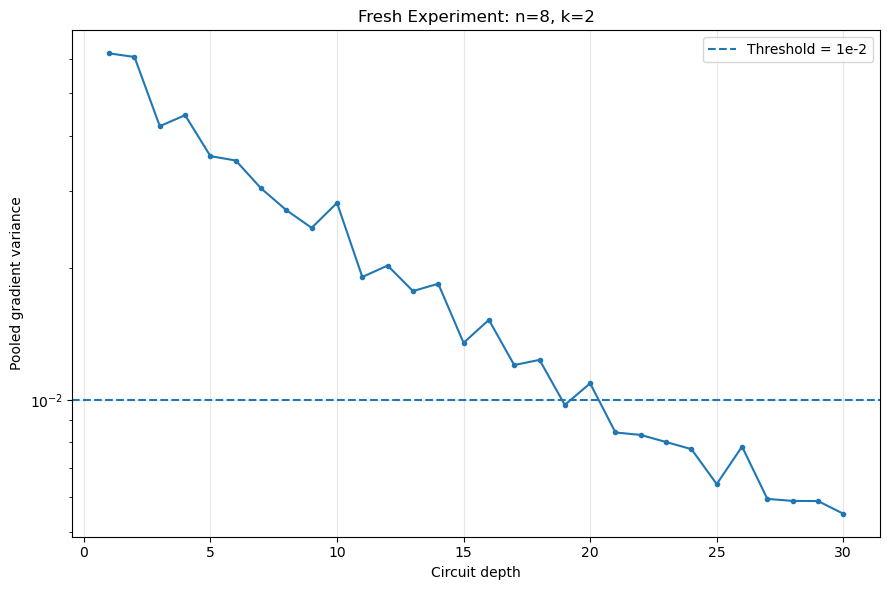

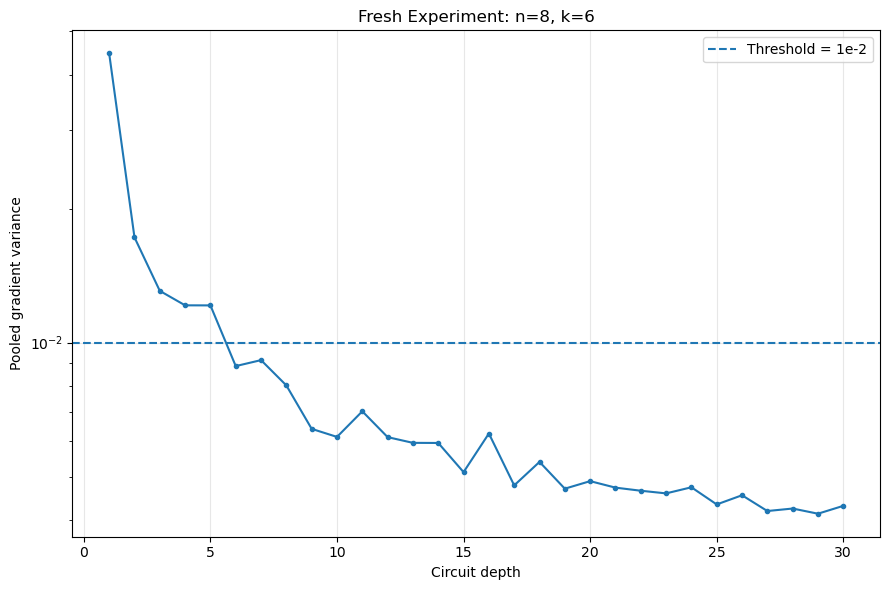

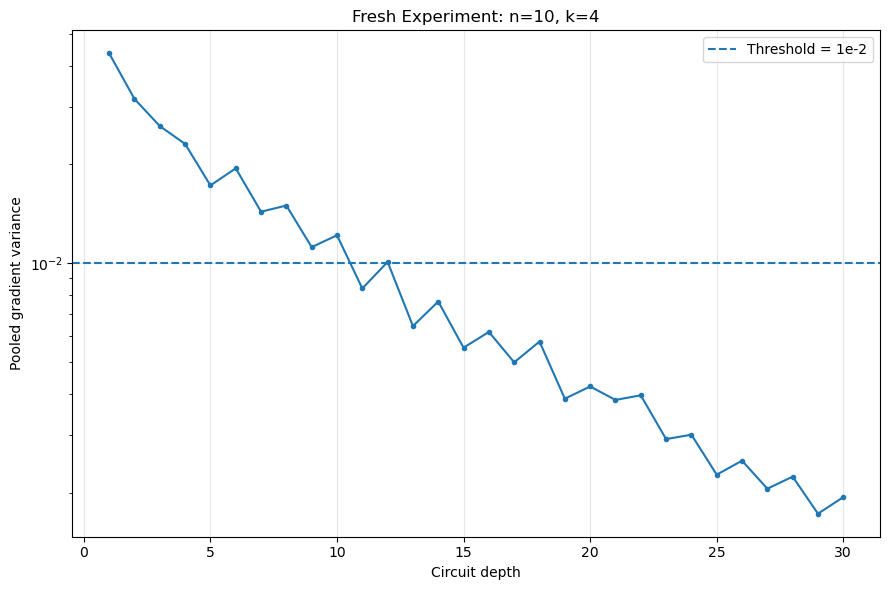

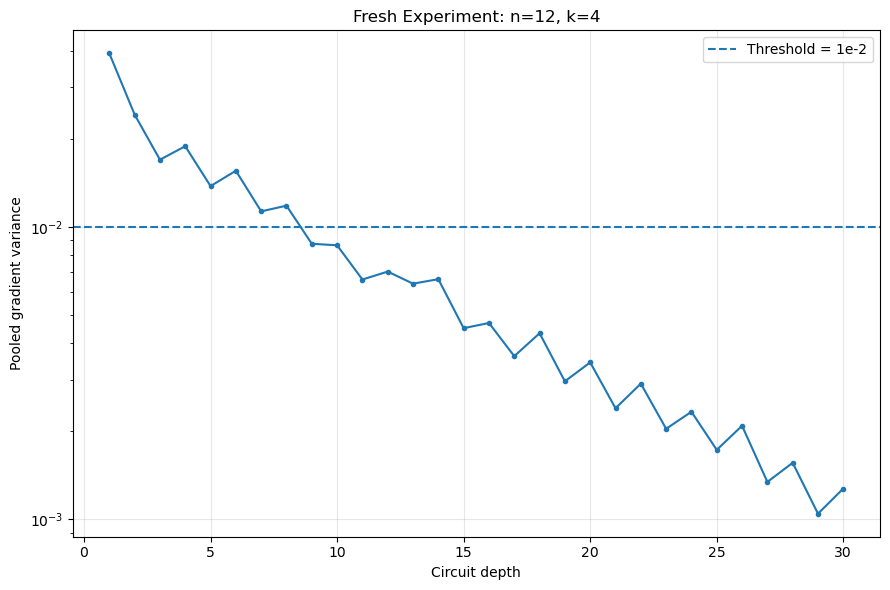

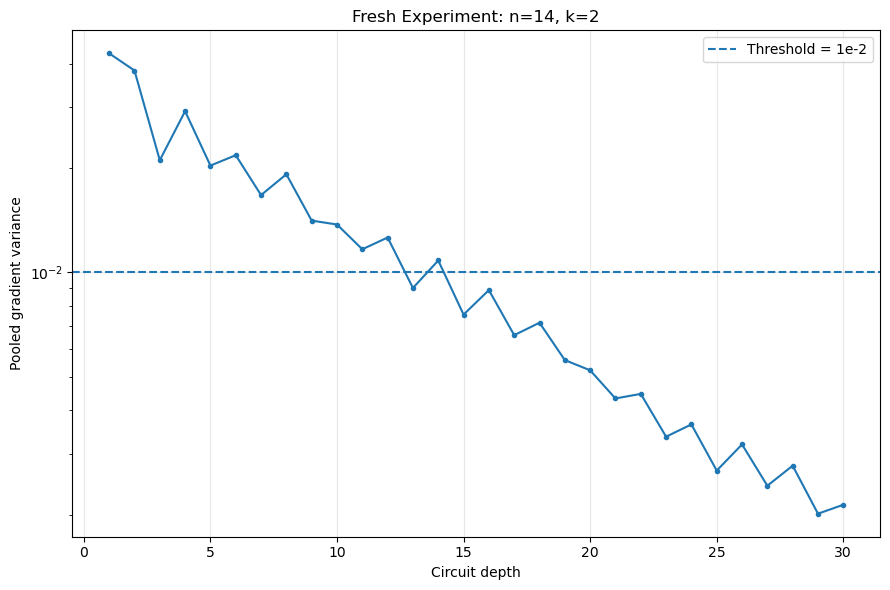

In [25]:
# ============================================================
# CELL 11 — FRESH VARIANCE CURVES
# ============================================================

for result in results:

    n = result["n"]
    k = result["k"]

    curve = result[
        "variance_curve"
    ]

    depths = np.arange(
        1,
        len(curve) + 1
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.semilogy(
        depths,
        curve,
        marker="o",
        markersize=3,
        linewidth=1.5
    )

    plt.axhline(
        THRESHOLD,
        linestyle="--",
        linewidth=1.5,
        label="Threshold = 1e-2"
    )

    plt.xlabel(
        "Circuit depth"
    )

    plt.ylabel(
        "Pooled gradient variance"
    )

    plt.title(
        f"Fresh Experiment: n={n}, k={k}"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"fresh_curve_n{n}_k{k}.png"
        ),
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()


### Cell 12 — Basic fresh-data integrity audit


In [26]:
# ============================================================
# CELL 12 — FRESH DATA INTEGRITY AUDIT
# ============================================================

print("=" * 80)
print("FRESH DATA INTEGRITY AUDIT")
print("=" * 80)

# Expected number of rows
expected_rows = (
    len(SPOT_CONFIGS)
    * MAX_DEPTH
)

print(
    f"Expected rows: {expected_rows:,}"
)

print(
    f"Actual rows:   {len(fresh_raw_df):,}"
)

if len(fresh_raw_df) != expected_rows:

    raise RuntimeError(
        "CRITICAL: Fresh raw dataset has unexpected row count."
    )

# Unique keys
duplicate_keys = (
    fresh_raw_df
    .groupby(
        ["n", "k", "depth"]
    )
    .size()
)

duplicate_keys = duplicate_keys[
    duplicate_keys > 1
]

print(
    "Duplicate keys:",
    len(duplicate_keys)
)

if len(duplicate_keys) > 0:

    raise RuntimeError(
        "CRITICAL: Duplicate fresh measurements found."
    )

# k <= n
invalid = fresh_raw_df[
    fresh_raw_df["k"]
    >
    fresh_raw_df["n"]
]

print(
    "Invalid k > n rows:",
    len(invalid)
)

if len(invalid) > 0:

    raise RuntimeError(
        "CRITICAL: Invalid k > n found."
    )

print(
    "\nPASS: Fresh dataset is structurally consistent."
)


FRESH DATA INTEGRITY AUDIT
Expected rows: 150
Actual rows:   150
Duplicate keys: 0
Invalid k > n rows: 0

PASS: Fresh dataset is structurally consistent.


### Cell 13 — Save protocol metadata


In [27]:
# ============================================================
# CELL 13 — SAVE EXPERIMENT PROVENANCE
# ============================================================

protocol = {
    "experiment_type":
        "independent_fresh_spot_reproduction",

    "source_data_used":
        False,

    "previous_results_used":
        False,

    "framework":
        "PennyLane",

    "framework_version":
        qml.__version__,

    "simulator":
        SIMULATOR,

    "architecture":
        "Brick-Wall hardware-efficient ansatz",

    "observable":
        "Z_0 tensor ... tensor Z_(k-1)",

    "initial_state":
        "|0>^n",

    "parameter_distribution":
        "Uniform(0, 2*pi)",

    "gradient_estimator":
        "Complete gradient vector per initialization; "
        "all components pooled across initializations; "
        "single variance over pooled array",

    "n_samples":
        N_SAMPLES,

    "max_depth":
        MAX_DEPTH,

    "threshold":
        THRESHOLD,

    "spot_configurations":
        [
            {
                "n": int(n),
                "k": int(k)
            }
            for n, k in SPOT_CONFIGS
        ],

    "master_seed":
        MASTER_SEED,
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "fresh_experiment_protocol.json"
    ),
    "w"
) as f:

    json.dump(
        protocol,
        f,
        indent=2
    )

print("=" * 80)
print("PROTOCOL SAVED")
print("=" * 80)

print(
    os.path.join(
        OUTPUT_DIR,
        "fresh_experiment_protocol.json"
    )
)


PROTOCOL SAVED
fresh_spot_reproduction\fresh_experiment_protocol.json


### Cell 14 — Final result


In [28]:
# ============================================================
# CELL 14 — FINAL FRESH EXPERIMENT SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("FRESH SPOT REPRODUCTION — FINAL SUMMARY")
print("=" * 90)

print(
    f"\nSimulator: {SIMULATOR}"
)

print(
    f"Samples per depth/configuration: {N_SAMPLES}"
)

print(
    f"Maximum depth: {MAX_DEPTH}"
)

print(
    f"Threshold: {THRESHOLD}"
)

print(
    "\nFresh tau_BP results:"
)

display(
    fresh_tau_df[
        [
            "n",
            "k",
            "tau_BP",
            "censored",
            "seed",
        ]
    ]
)

print(
    "\nThe experiment was generated independently "
    "from the methodological specification."
)

print(
    "No historical variance_curves.csv was loaded."
)

print(
    "No historical A/c values were used."
)

print(
    "No historical tau values were used."
)

print(
    "\nSTATUS: FRESH EXPERIMENT COMPLETE"
)



FRESH SPOT REPRODUCTION — FINAL SUMMARY

Simulator: lightning.qubit
Samples per depth/configuration: 50
Maximum depth: 30
Threshold: 0.01

Fresh tau_BP results:


,n,k,tau_BP,censored,seed
0,8,2,19,False,3373383951
1,8,6,6,False,2715193214
2,10,4,11,False,3562792977
3,12,4,9,False,2501418362
4,14,2,13,False,3383362091



The experiment was generated independently from the methodological specification.
No historical variance_curves.csv was loaded.
No historical A/c values were used.
No historical tau values were used.

STATUS: FRESH EXPERIMENT COMPLETE


### What this gives us

This produces:

```text
fresh_spot_reproduction/
├── fresh_variance_curves.csv
├── fresh_tau_results.csv
├── fresh_experiment_protocol.json
├── checkpoints/
│   └── fresh_spot_checkpoint.pkl
├── fresh_curve_n8_k2.png
├── fresh_curve_n8_k6.png
├── fresh_curve_n10_k4.png
├── fresh_curve_n12_k4.png
└── fresh_curve_n14_k2.png
```

The critical point is that **the experiment does not read `variance_curves.csv` at all**. The only predefined things are the experimental protocol and the selected spot configurations. The actual variances and \(\tau_{BP}\) are generated fresh.

After it finishes, **do not modify the outputs based on what you expect to see**. Send me the Cell 14 output and the five fresh curve plots. Then we will compare this independent experiment against `variance_curves.csv`. That comparison—not simply the fact that the new run executes—is what will tell us whether the old dataset is trustworthy.
